# Ільніцька Вікторія Сергіївна
<span style="color: red;">ІПЗ-23007б</span>

**Номер варіанту: 6**

In [1]:
import platform
import os
import sys

print("ОС:", platform.system(), platform.version())
print("Шлях до папки проекту:", os.getcwd())
print("Назва віртуального оточення:", os.path.basename(sys.prefix))

ОС: Linux #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
Шлях до папки проекту: /home/jovyan
Назва віртуального оточення: conda


### 1. Створити програму для генерації довільного масиву із 60 цілих чисел, які не перевищують по модулю 255, з наступними властивостями:
1. При кожному запуску програми масив повинен бути різним
2. Щонайменше 2 останніх елементи повинні бути від'ємними
3. Масив повинен містити 40 відсотків додатних елементів (розташованих в довільних місцях)

In [2]:
import random
import numpy as np

n = 60
n_positive = int(n * 0.4)

positive_i = set(random.sample(range(58), n_positive))

arr = []
for i in range(n):
    if i in positive_i:
        arr.append(random.randint(1, 255))
    else:
        arr.append(random.randint(-255, -1))

arr = np.array(arr)
print(arr)

[-112   39 -235  -16 -165  200 -144  -47 -247  -30    2  -27  -49  -57
 -105 -182   66   29  107   71  170   59   24 -222  209  238 -248 -104
 -128 -105  248 -122  169  -40  249   49 -231  166 -241 -242 -136  -49
   28  170  -72   60 -136  214 -199  -51 -129 -109   20  -36 -169  169
  123 -229 -214 -124]


### 2. Зберегти в згенерований файл.

In [3]:
np.savetxt("arr_6.txt", arr, fmt="%d")
print("Saved in arr_6.txt")

Saved in arr_6.txt


### 3. Створити програму, яка зчитує із файлу згенерований масив попередньою програмою і виводить його на екран.

In [4]:
arr_loaded = np.loadtxt("arr_6.txt", dtype=int)
print(arr_loaded)

[-112   39 -235  -16 -165  200 -144  -47 -247  -30    2  -27  -49  -57
 -105 -182   66   29  107   71  170   59   24 -222  209  238 -248 -104
 -128 -105  248 -122  169  -40  249   49 -231  166 -241 -242 -136  -49
   28  170  -72   60 -136  214 -199  -51 -129 -109   20  -36 -169  169
  123 -229 -214 -124]


### 4. Візуалізувати масив за допомогою діаграми тпиу графік. Виділити кольором рівні, які відповідають максимальним та мінімальним елементам, а також вказати ці значення на діаграмі. Виділити іншим кольором сектори, які відповідають додатнім елементам.

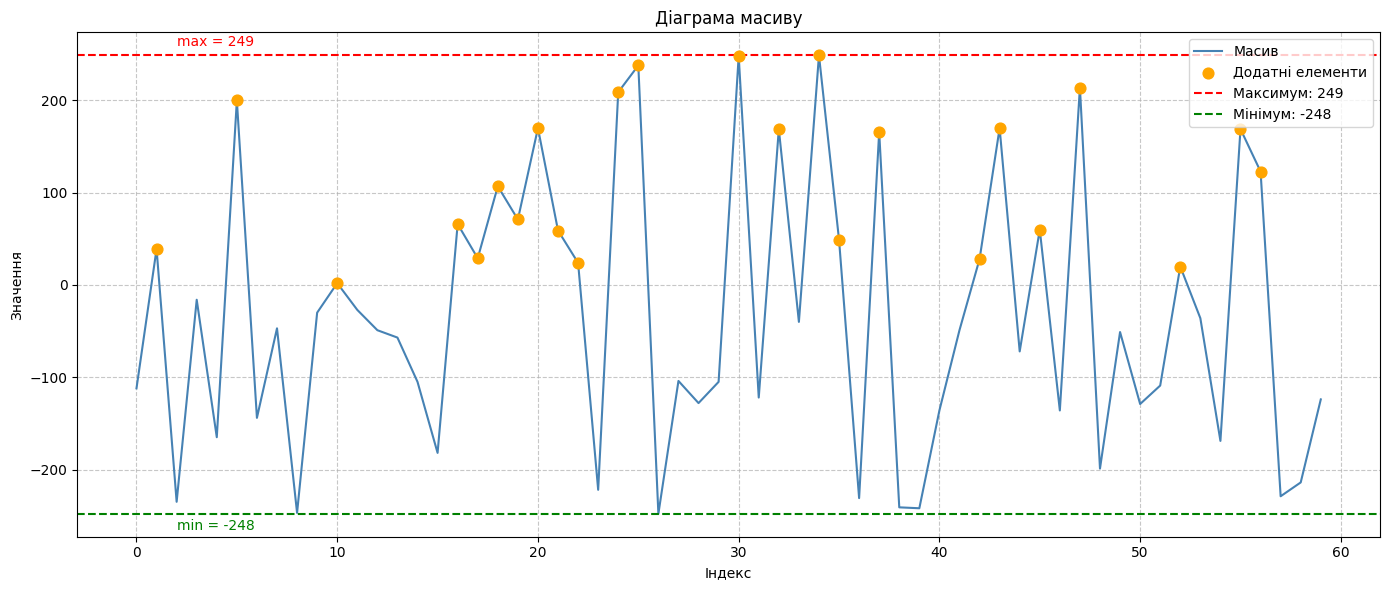

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))

max_val = arr_loaded.max()
min_val = arr_loaded.min()

x = np.arange(len(arr_loaded))

ax.plot(x, arr_loaded, color='steelblue', linewidth=1.5, zorder=2, label='Масив')

pos_mask = arr_loaded > 0
ax.scatter(x[pos_mask], arr_loaded[pos_mask], color='orange', s=60, zorder=3, label='Додатні елементи')

ax.axhline(y=max_val, color='red', linestyle='--', linewidth=1.5, label=f'Максимум: {max_val}')
ax.axhline(y=min_val, color='green', linestyle='--', linewidth=1.5, label=f'Мінімум: {min_val}')

ax.annotate(f'max = {max_val}', xy=(0, max_val), xytext=(2, max_val + 10), color='red', fontsize=10)
ax.annotate(f'min = {min_val}', xy=(0, min_val), xytext=(2, min_val - 18), color='green', fontsize=10)

ax.set_title('Діаграма масиву')
ax.set_xlabel('Індекс')
ax.set_ylabel('Значення')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 5. Порахувати кількість та суму елементів масиву, розташованих між мінімальним та другим мінімальним елементами.

In [6]:
min_val = arr_loaded.min()
sorted_unique = np.unique(arr_loaded)
second_min_val = sorted_unique[1]

min_idx = np.where(arr_loaded == min_val)[0][0]
second_min_idx = np.where(arr_loaded == second_min_val)[0][0]

left = min(min_idx, second_min_idx)
right = max(min_idx, second_min_idx)

between = arr_loaded[left+1:right]

print(f"Мінімальний елемент: {min_val}, індекс: {min_idx}")
print(f"Другий мінімальний елемент: {second_min_val}, індекс: {second_min_idx}")
print(f"Елементи між ними: {between}")
print(f"Кількість: {len(between)}")
print(f"Сума: {between.sum()}")

Мінімальний елемент: -248, індекс: 26
Другий мінімальний елемент: -247, індекс: 8
Елементи між ними: [ -30    2  -27  -49  -57 -105 -182   66   29  107   71  170   59   24
 -222  209  238]
Кількість: 17
Сума: 303


### 6. Порахувати кількість елементів масиву, розташованих між першим і останнім додатними елементами.

In [7]:
pos_indices = np.where(arr_loaded > 0)[0]

first_pos_idx = pos_indices[0]
last_pos_idx = pos_indices[-1]

between = arr_loaded[first_pos_idx+1:last_pos_idx]

print(f"Перший додатній елемент: {arr_loaded[first_pos_idx]}, індекс: {first_pos_idx}")
print(f"Останній додатній елемент: {arr_loaded[last_pos_idx]}, індекс: {last_pos_idx}")
print(f"Кількість елементів між ними: {len(between)}")

Перший додатній елемент: 39, індекс: 1
Останній додатній елемент: 123, індекс: 56
Кількість елементів між ними: 54


### 7. Перетворити масив таким чином, щоб спочатку йшли від'ємні елементи, відсортовані за спаданням, потім додатні елементи, відсортовані за зростанням. Вивести отриманий масив та його графічну діаграму на екран.

[ -16  -27  -30  -36  -40  -47  -49  -49  -51  -57  -72 -104 -105 -105
 -109 -112 -122 -124 -128 -129 -136 -136 -144 -165 -169 -182 -199 -214
 -222 -229 -231 -235 -241 -242 -247 -248    2   20   24   28   29   39
   49   59   60   66   71  107  123  166  169  169  170  170  200  209
  214  238  248  249]


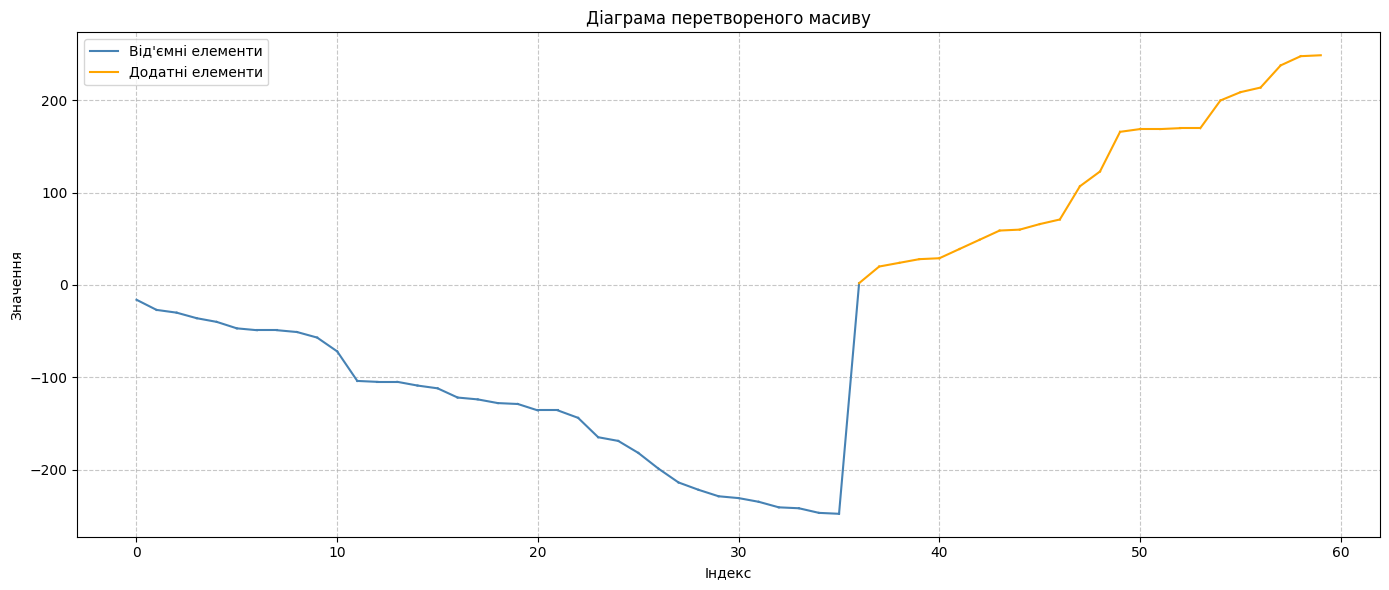

In [8]:
negative = np.sort(arr_loaded[arr_loaded < 0])[::-1]
positive = np.sort(arr_loaded[arr_loaded > 0])

arr_transformed = np.concatenate([negative, positive])

print(arr_transformed)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(arr_transformed))

for i in range(len(arr_transformed) - 1):
    color = 'orange' if arr_transformed[i] > 0 else 'steelblue'
    ax.plot(x[i:i+2], arr_transformed[i:i+2], color=color, linewidth=1.5)

ax.plot([], [], color='steelblue', linewidth=1.5, label='Від\'ємні елементи')
ax.plot([], [], color='orange', linewidth=1.5, label='Додатні елементи')

ax.set_title('Діаграма перетвореного масиву')
ax.set_xlabel('Індекс')
ax.set_ylabel('Значення')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()